In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class LeNet(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(out_channels=6, kernel_size=5, stride=1, padding=0),
            nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes)
        )
    
    def forward(self, X):
        return self.net(X)

X = torch.randn(1, 1, 28, 28).to('cuda')
model = LeNet(num_classes=10).to('cuda')
model(X).shape

c:\Users\janba\anaconda3\envs\workspace_jan\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


torch.Size([1, 10])

In [3]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,), (0.5,))])

train_set = torchvision.datasets.MNIST(root="../datasets", train=True, download=True, transform=transform)

test_val_set = torchvision.datasets.MNIST(root="../datasets", train=False, download=True, transform=transform)
X_test_val, y_test_val = zip(*test_val_set)
X_test_val = torch.stack(X_test_val)
y_test_val = torch.tensor(y_test_val)

test_idx, val_idx = torch.utils.data.random_split(y_test_val, [5000, 5000])

X_test = X_test_val[test_idx.indices]
y_test = y_test_val[test_idx.indices]

X_val = X_test_val[val_idx.indices]
y_val = y_test_val[val_idx.indices]

train_set.data.shape, train_set.targets.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

(torch.Size([60000, 28, 28]),
 torch.Size([60000]),
 torch.Size([5000, 1, 28, 28]),
 torch.Size([5000]),
 torch.Size([5000, 1, 28, 28]),
 torch.Size([5000]))

In [4]:
EPOCHS = 10

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

lenet = LeNet(num_classes=10).to('cuda')

optimizer = torch.optim.Adam(lenet.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_history = []
val_history = []

for epoch in range(EPOCHS):
    batch_history = []
    for i, (images, labels) in enumerate(train_loader):
        # predict and compute loss
        preds = lenet(images.to('cuda'))
        loss = criterion(preds, labels.to('cuda'))
        batch_history.append(loss.item())
        # optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_history.append(torch.mean(torch.tensor(batch_history)))

    with torch.no_grad():
        preds = lenet(X_val.to('cuda'))
        loss = criterion(preds, y_val.to('cuda'))
        val_history.append(loss.item())
    
    print(f"epoch {epoch}, train_loss {train_history[-1]}, val_loss {val_history[-1]}")

with torch.no_grad():
    preds = lenet(X_test.to('cuda'))
    loss = criterion(preds, y_test.to('cuda'))
    print(f"test_loss {loss.item()}")

c:\Users\janba\anaconda3\envs\workspace_jan\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


epoch 0, train_loss 0.847640335559845, val_loss 0.18874701857566833
epoch 1, train_loss 0.16088774800300598, val_loss 0.10475174337625504
epoch 2, train_loss 0.10727230459451675, val_loss 0.07639611512422562
epoch 3, train_loss 0.08452320843935013, val_loss 0.06402081996202469
epoch 4, train_loss 0.06985197961330414, val_loss 0.059031371027231216
epoch 5, train_loss 0.06043757498264313, val_loss 0.05215786024928093
epoch 6, train_loss 0.0528552308678627, val_loss 0.04606347531080246
epoch 7, train_loss 0.047023944556713104, val_loss 0.05207425355911255
epoch 8, train_loss 0.04316490516066551, val_loss 0.04111456125974655
epoch 9, train_loss 0.039398226886987686, val_loss 0.03708872199058533
test_loss 0.043933797627687454


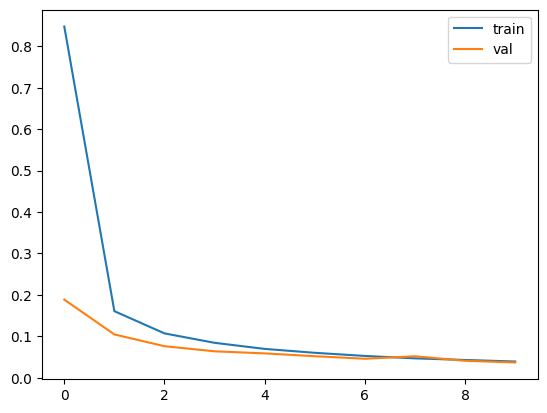

In [5]:
plt.plot(train_history, label='train')
plt.plot(val_history, label='val')
plt.legend()

In [ ]:
import copy

M = 10

x = torch.randn(M, 1, 28, 28, requires_grad=True, device='cuda')
lr = torch.rand(1, requires_grad=True, device='cuda')

base_model = LeNet(num_classes=10).to('cuda')
base_model(torch.randn(M, 1, 28, 28).to('cuda'))

labels = torch.arange(0, 10, 1).to('cuda')

loss = nn.CrossEntropyLoss()

x_lr_optim = torch.optim.Adam([x, lr], lr=0.03)
# lr_optim = torch.optim.Adam([lr], lr=0.1)

EPOCHS = 2000

for e in range(EPOCHS):

    # model = copy.deepcopy(base_model)
    model = copy.deepcopy(lenet)
    
    preds = model(x)
    loss = criterion(preds, labels)

    loss.backward()

    x.grad.zero_()
    
    for p in model.parameters():
        p = p - lr * p.grad

    preds = model(x)
    loss = criterion(preds, labels)

    loss.backward()

    x_lr_optim.step()

    x_lr_optim.zero_grad()

    print(e, loss.item())


c:\Users\janba\anaconda3\envs\workspace_jan\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


0 7.874611854553223
1 6.6006903648376465
2 5.334366321563721
3 4.314810276031494
4 3.625936985015869
5 3.0593650341033936
6 2.5145044326782227
7 2.0330264568328857
8 1.6498034000396729
9 1.3730545043945312
10 1.1763942241668701
11 1.0097604990005493
12 0.8572301864624023
13 0.7176666259765625
14 0.595317542552948
15 0.48830002546310425
16 0.3897083103656769
17 0.2996440529823303
18 0.22182877361774445
19 0.15990227460861206
20 0.11302785575389862
21 0.07944909483194351
22 0.05595958232879639
23 0.040576353669166565
24 0.03036031685769558
25 0.023485450074076653
26 0.018849870190024376
27 0.015610759146511555
28 0.01328026782721281
29 0.011552615091204643
30 0.01023460365831852
31 0.009209985844790936
32 0.008387008681893349
33 0.007727686315774918
34 0.0071871159598231316
35 0.006742500700056553
36 0.006365021225064993
37 0.006034564692527056
38 0.005738510750234127
39 0.005482460372149944
40 0.005251626018434763
41 0.005043907091021538
42 0.004857187159359455
43 0.004689968191087246
4

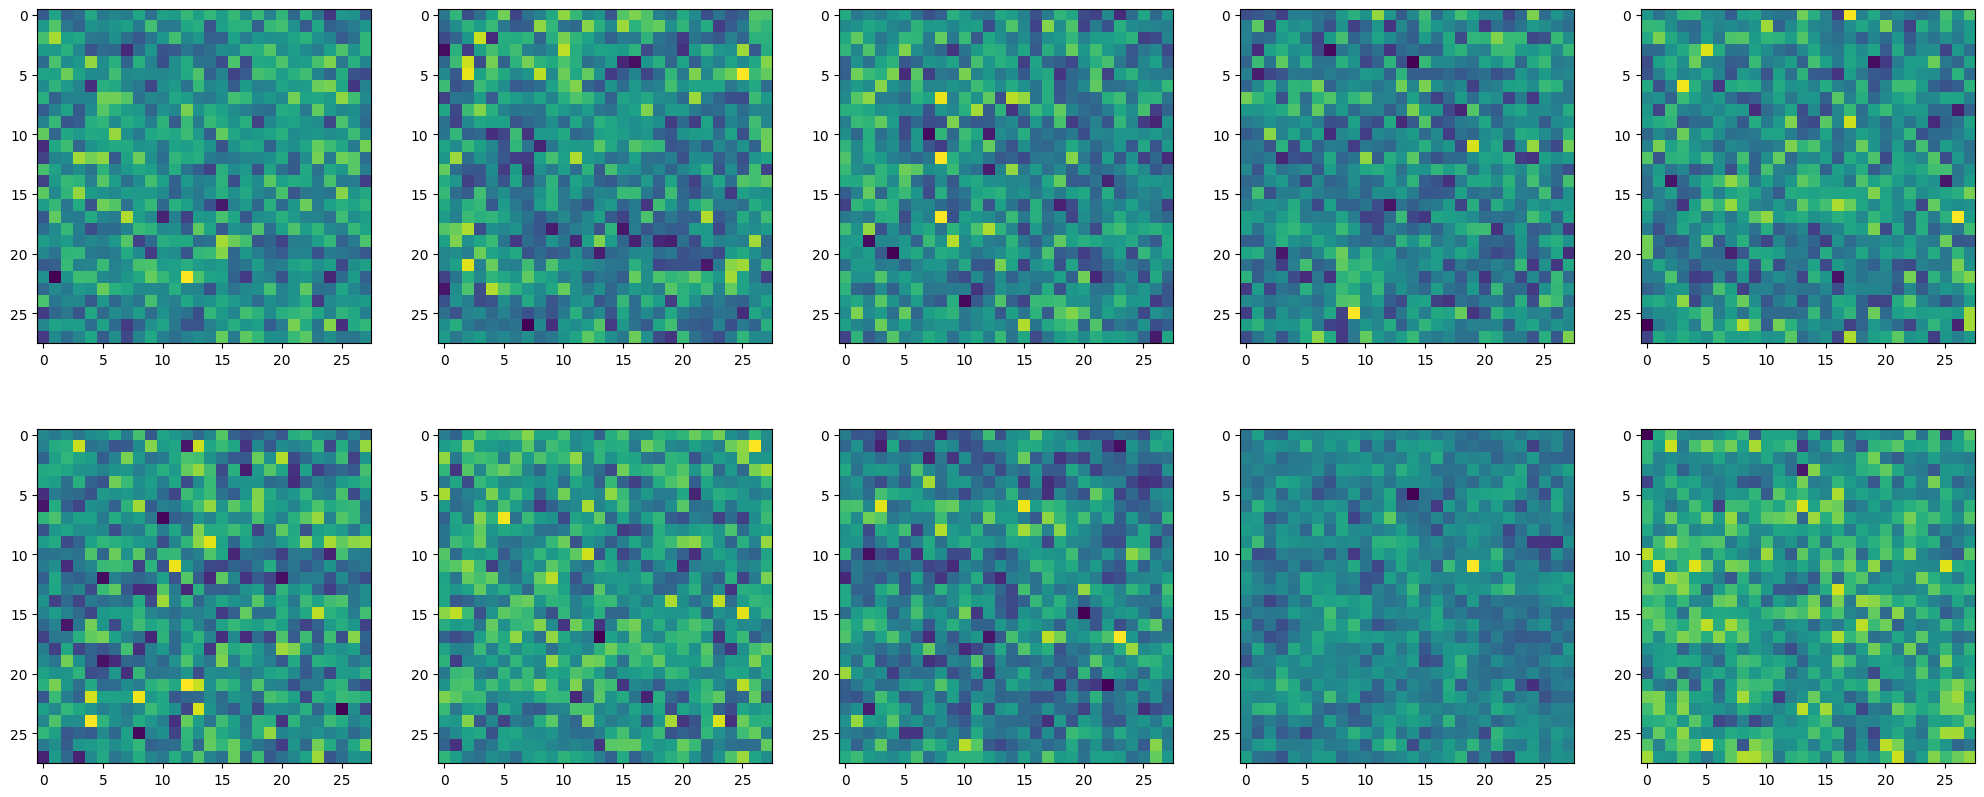

In [97]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for ax, c in zip(axes, x.detach().cpu().numpy()):

    ax.imshow(c.squeeze())
